---
# A Unified Python Framework for Classical and Novel Seismic Enhancement and Multi-Domain Spectral Interpretation 
---
#### ___Yasir Bashir___ <br>
Geophysical Engineering, Faculty of Mines, Istanbul Technical University, Turkey

### 1- Import necessary libraries


In [244]:
import matplotlib.pyplot as plt
from obspy.io.segy.segy import _read_segy
from obspy.core import Trace, Stream
from tkinter import *
from tkinter import filedialog
import segyio 
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

import os
from obspy import read
import numpy as np
from scipy.signal import hilbert

### 2- Seismic Data Loading


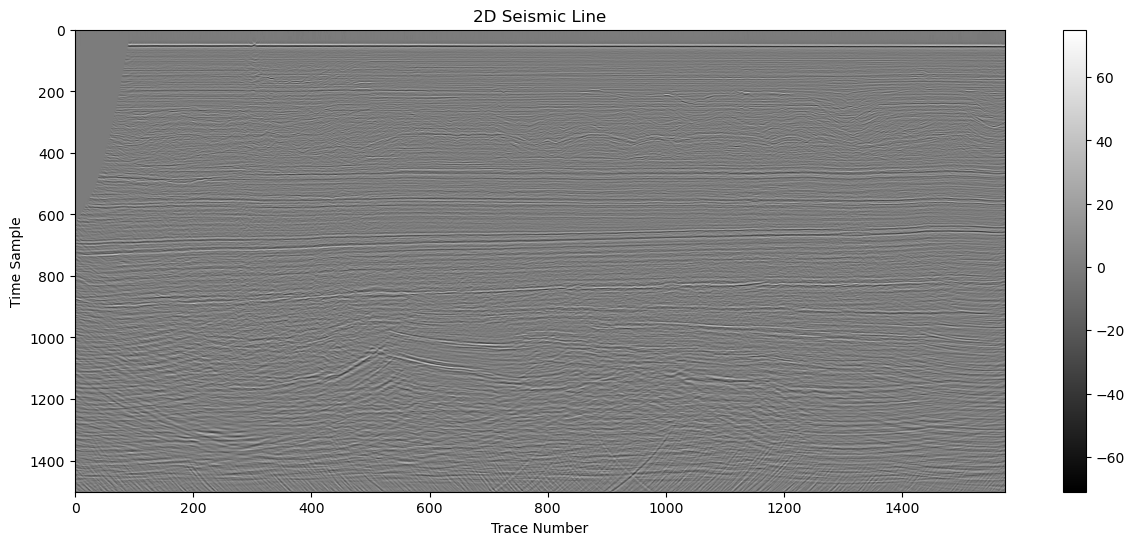

In [247]:
with segyio.open("C:/Users/yasir/Jupyter-YB/0. Seismic ML/Data.segy", "r", ignore_geometry=True) as segy:
    data = segy.trace.raw[:]   # shape = (n_traces, n_samples)


plt.figure(figsize=(15, 6))
plt.imshow(data.T, cmap="grey", aspect="auto")
plt.title("2D Seismic Line")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
plt.colorbar()
#plt.gca().invert_yaxis()   # makes time increase downward

#to save figure as png
plt.savefig("1. Origional seismic_line.jpg", dpi=600, bbox_inches="tight")

plt.show()
data_linear=data.T

#### 2.1 - Amplitude Spectrum : Original Data Loaded

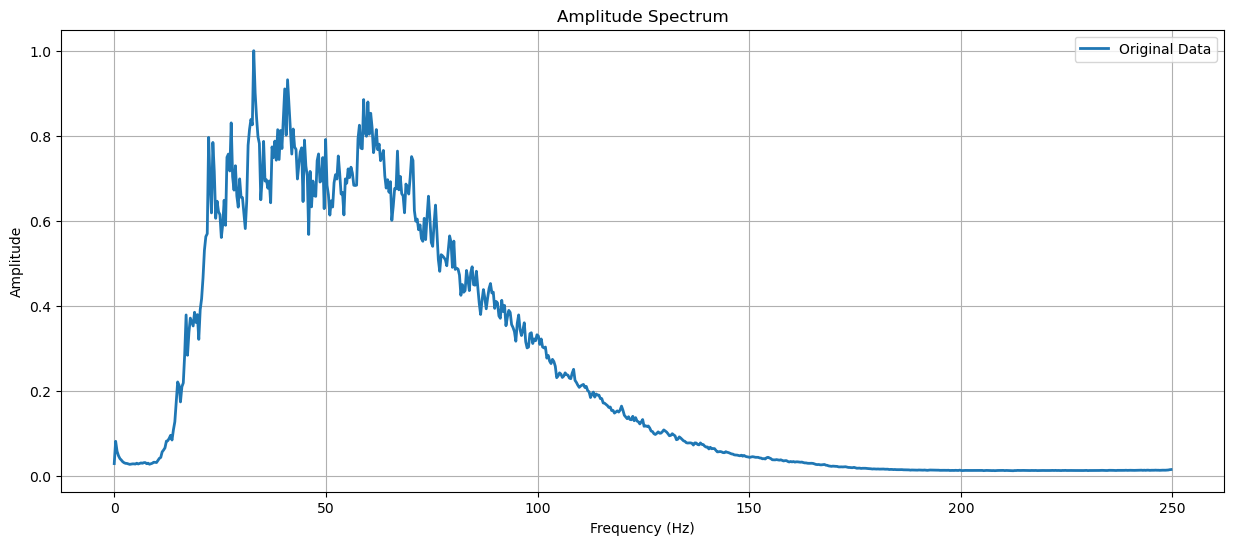

In [249]:
def plot_amplitude_spectrum_ori(data, dt, label):

    # number of samples
    n_traces, n_samples = data.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_ori(data, dt, "Original Data")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum_Comparison.jpg", dpi=600, bbox_inches="tight")

plt.show()


### 3 - Automatic Gain Control (AGC) - Applications to the ata

C:\Users\yasir\AppData\Local\Temp\ipykernel_25544\1038968137.py:14: RuntimeWarning: invalid value encountered in sqrt
  rms = np.sqrt(
C:\Users\yasir\AppData\Local\Temp\ipykernel_25544\1038968137.py:23: RuntimeWarning: invalid value encountered in cast
  agc_data[i] = trace / rms


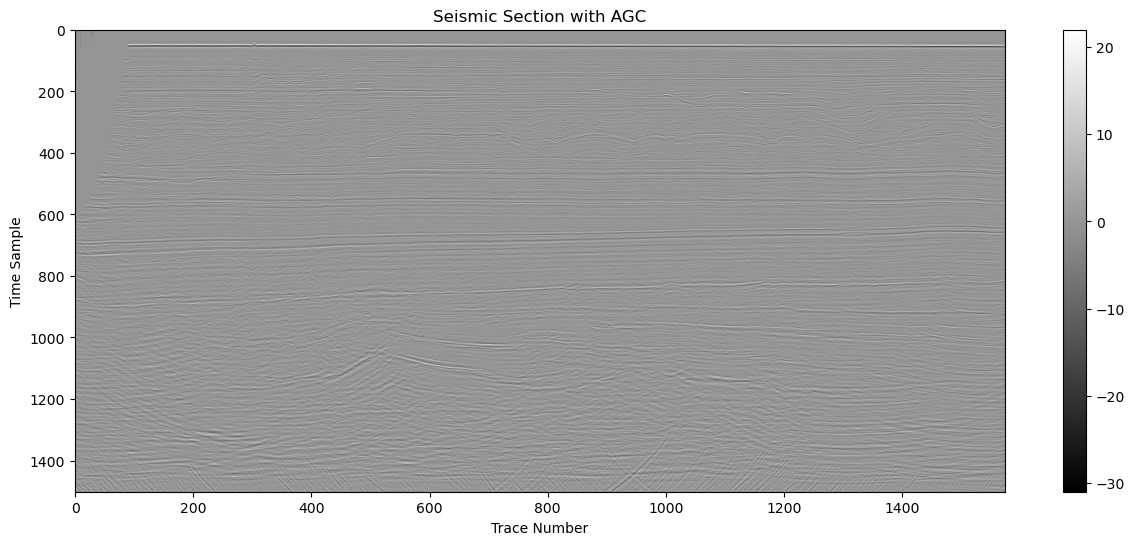

In [286]:
# -----------------------------
# AGC Function
# -----------------------------
def apply_agc(data, window):
    
    n_traces, n_samples = data.shape
    agc_data = np.zeros_like(data)

    for i in range(n_traces):

        trace = data[i]

        # RMS calculation using moving window
        rms = np.sqrt(
            np.convolve(trace**2,
                        np.ones(window)/window,
                        mode='same')
        )

        # avoid division by zero
        rms[rms == 0] = 1e-10

        agc_data[i] = trace / rms

    return agc_data


# -----------------------------
# Apply AGC
# -----------------------------
window = 1000   # adjust depending on data
data_agc = apply_agc(data, window)

# -----------------------------
# Plot AGC Result
# -----------------------------
plt.figure(figsize=(15,6))
plt.imshow(data_agc.T, cmap='grey', aspect='auto')
plt.title("Seismic Section with AGC")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
#to save figure as png
plt.savefig("2. AGC seismic_line.jpg", dpi=600, bbox_inches="tight")

plt.colorbar()
#plt.gca().invert_yaxis()
plt.show()

In [252]:
data_agc

array([[ 0,  0,  0, ...,  0, -1, -1],
       [ 0,  0,  0, ..., -3, -3, -1],
       [-5, -2, -2, ...,  0, -5, -3],
       ...,
       [ 0,  0,  0, ...,  2,  0, -1],
       [ 0,  0,  0, ...,  0, -1,  0],
       [ 0,  0,  0, ..., -2, -1,  0]], dtype=int8)

In [253]:
data

array([[  0,   0,   0, ...,  -3,  -6,  -5],
       [  0,   0,   0, ..., -13, -13,  -6],
       [ -2,  -1,  -1, ...,   0, -16, -12],
       ...,
       [  0,   0,   0, ...,   6,  -2,  -3],
       [ -1,   0,  -1, ...,   0,  -5,  -3],
       [  0,   0,   0, ...,  -6,  -4,  -1]], dtype=int8)

#### 3.1 - Amplitude Spectrum : AGC Data

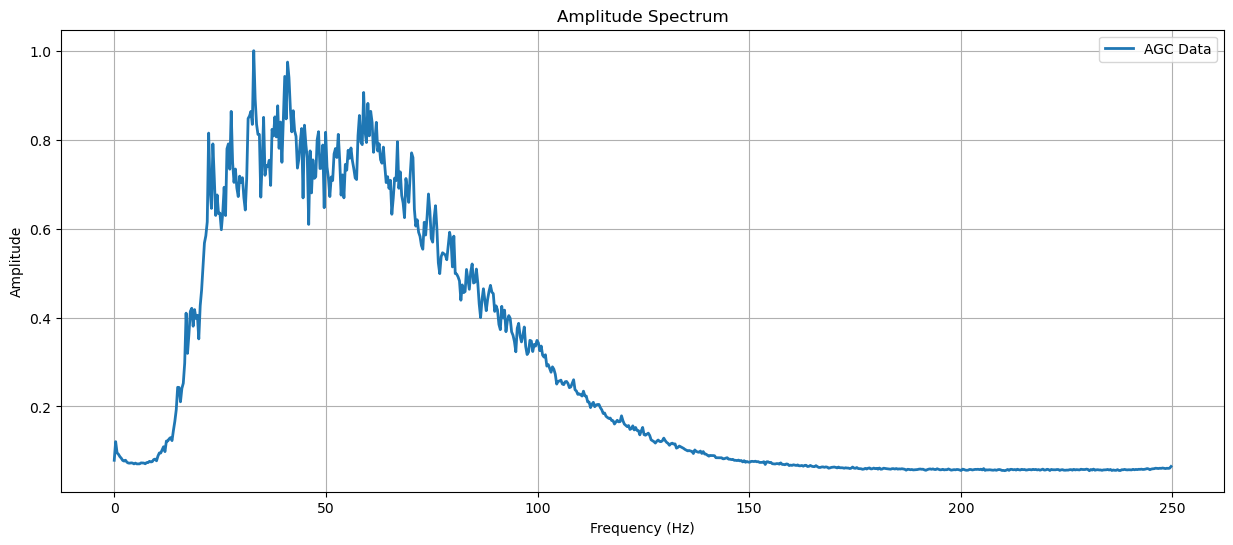

In [255]:
def plot_amplitude_spectrum_agc(data_agc, dt, label):

    # number of samples
    n_traces, n_samples = data_agc.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data_agc, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_agc(data_agc, dt, "AGC Data")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum.jpg", dpi=600, bbox_inches="tight")

plt.show()

### 4 - Linear Gain - Applications on Seismic  Data

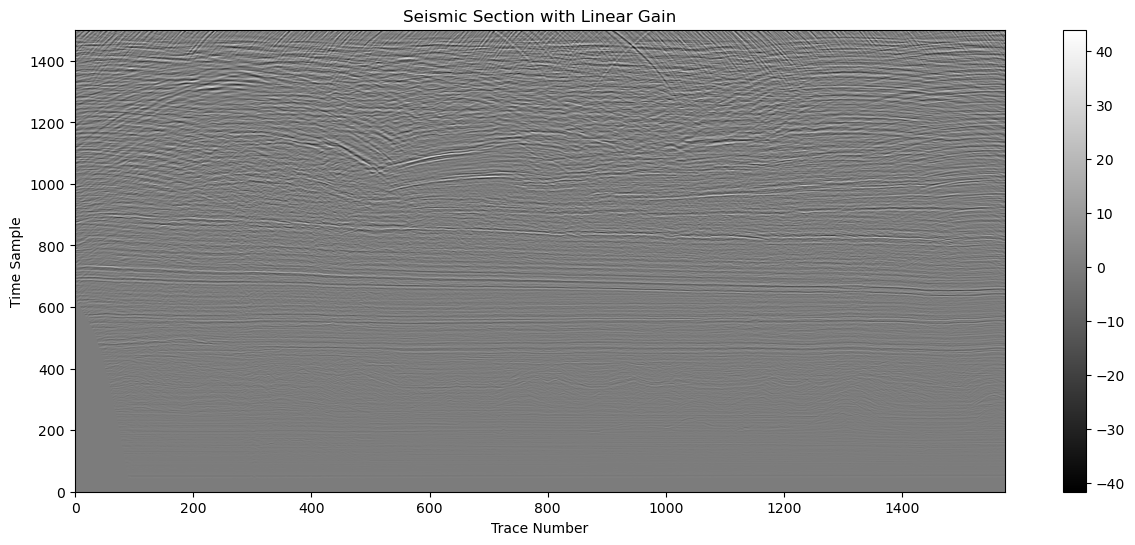

In [293]:
# -----------------------------
# Define linear gain
# -----------------------------
n_traces, n_samples = data.shape

# create time index
time = np.arange(n_samples)

# normalize time (0 → 1)
linear_gain = time / np.max(time)

# apply gain to all traces
data_linear_gain = data * linear_gain

# -------------------------------------------------------
#n_traces, n_samples = data.shape
#time = np.arange(n_samples)

#linear_gain = time / np.max(time)
#data_linear = data * linear_gain

# -----------------------------
# Plot linear gain result
# -----------------------------
plt.figure(figsize=(15,6))
plt.imshow(data_linear_gain.T, cmap="gray", aspect="auto")
plt.title("Seismic Section with Linear Gain")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
plt.gca().invert_yaxis()
plt.colorbar()
#to save figure as png
plt.savefig("5. linear gain.jpg", dpi=600, bbox_inches="tight")
plt.show()

#### 4.1 - Amplitude Spectrum : Linear Gain Data

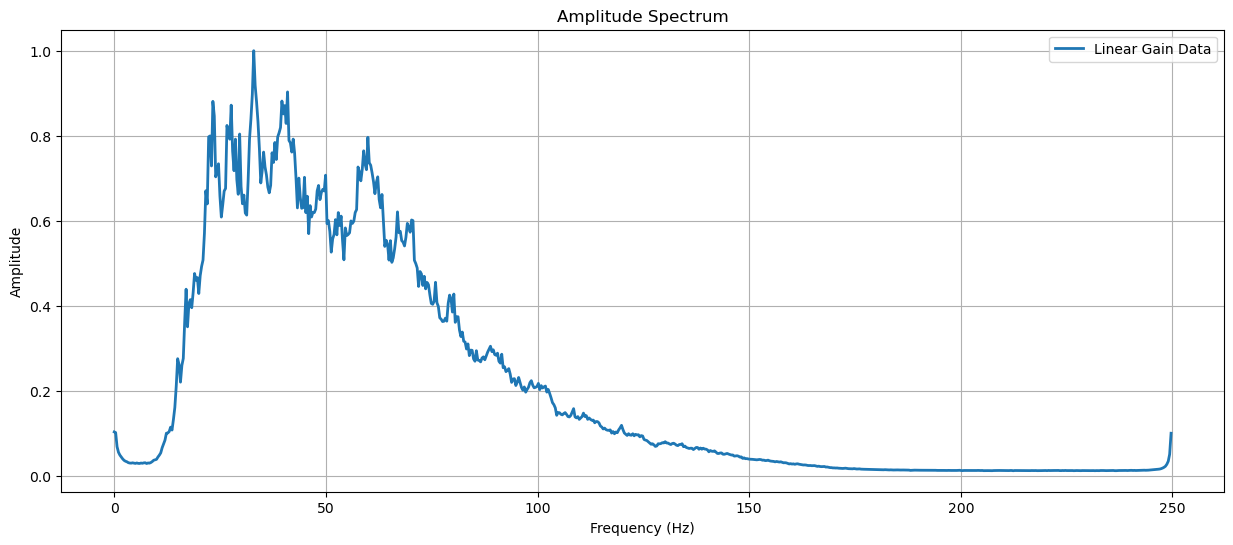

In [259]:
def plot_amplitude_spectrum_linear(data_linear_gain, dt, label):

    # number of samples
    n_traces, n_samples = data_linear_gain.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data_linear_gain, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_linear(data_linear_gain, dt, "Linear Gain Data")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum.jpg", dpi=600, bbox_inches="tight")

plt.show()

### 5 - Power (Exponential) Gain : Applications on Seismic Data

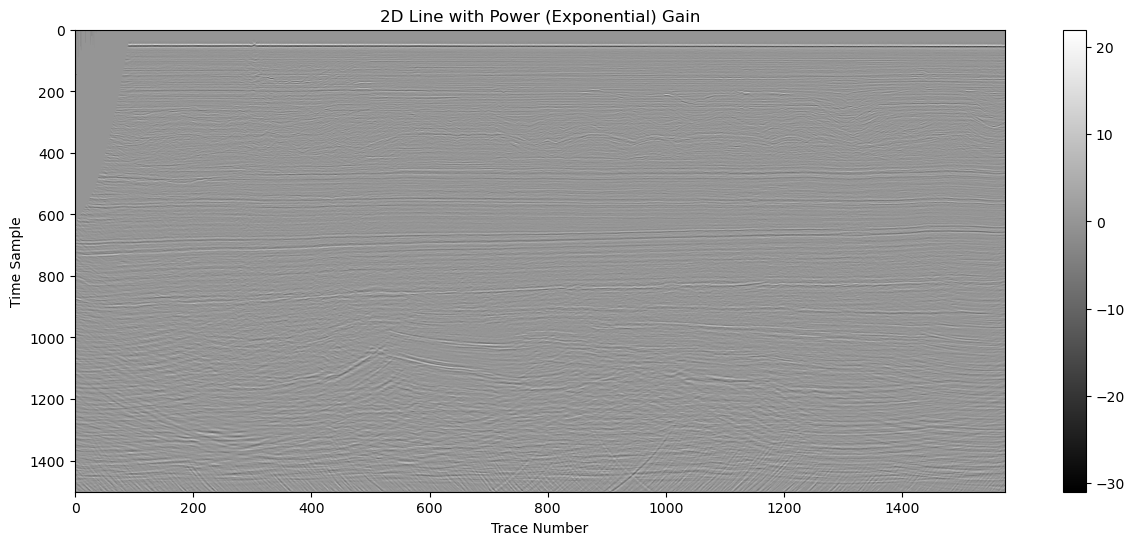

In [261]:
p = 1.5  # change gain strength
time = np.arange(n_samples)

power_gain = (time / np.max(time))**p
data_power = data * power_gain

#Ploting data

plt.figure(figsize=(15, 6))
plt.imshow(data_agc.T, cmap="gray", aspect="auto")
plt.title("2D Line with Power (Exponential) Gain")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
plt.colorbar()
#plt.gca().invert_yaxis()

#to save figure as png
plt.savefig("7. power exponential gain.jpg", dpi=600, bbox_inches="tight")

plt.show()

#### 5.1 - Amplitude Specturm : Power (Exponential) Gain

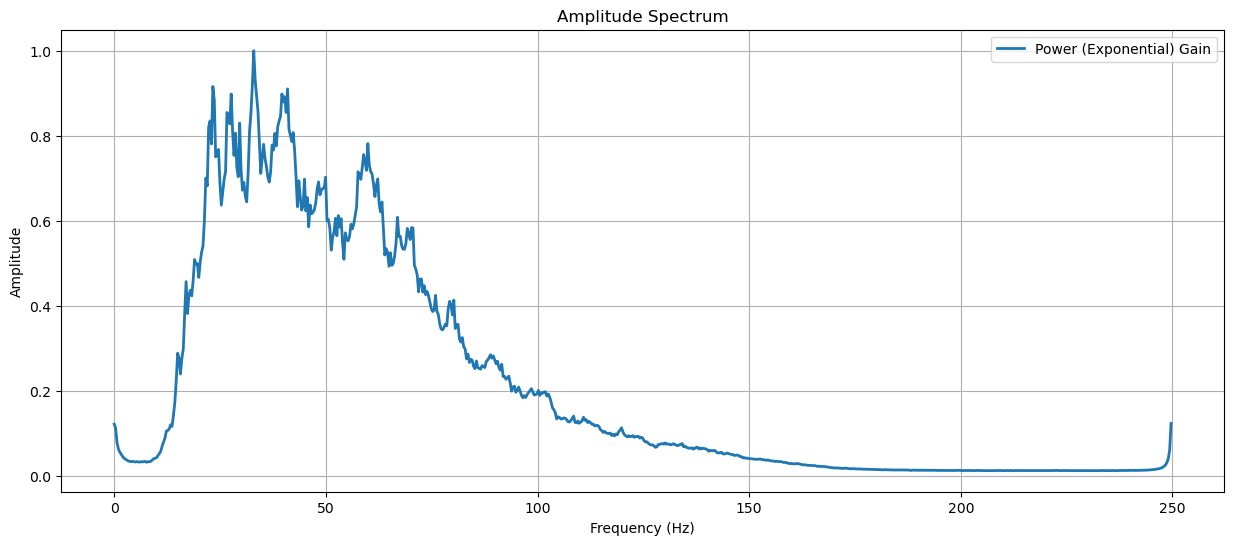

In [263]:
def plot_amplitude_spectrum_power(data_power, dt, label):

    # number of samples
    n_traces, n_samples = data_power.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data_power, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_power(data_power, dt, "Power (Exponential) Gain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum.jpg", dpi=600, bbox_inches="tight")

plt.show()

### 6 - Exponential Gain: Applications on Seismic Data

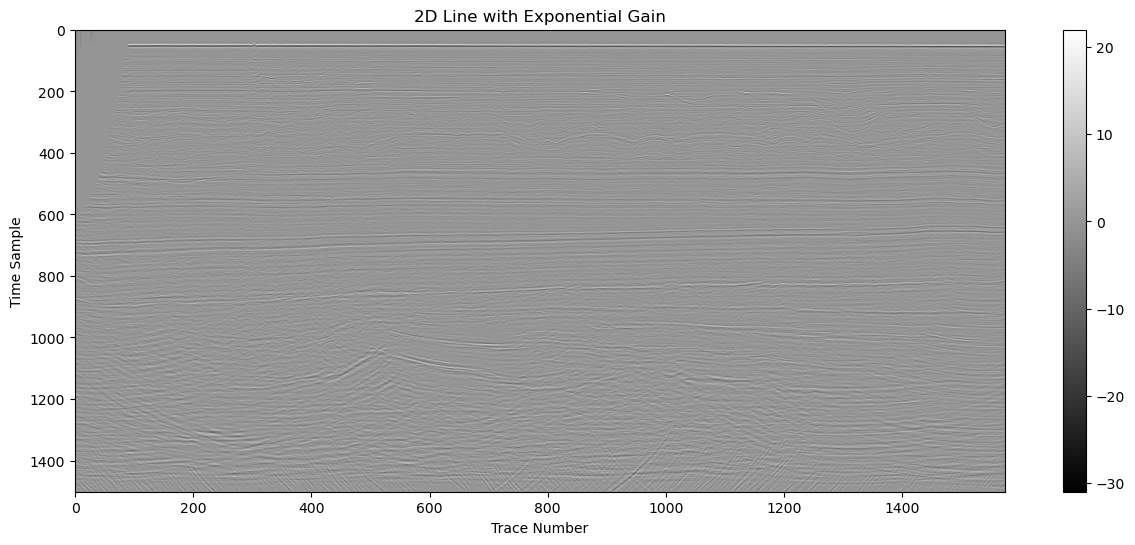

In [265]:
dt = 0.002    # sample rate in seconds (example: 2 ms)
t = np.arange(n_samples) * dt

alpha = 2.0   # increase or decrease gain strength
exp_gain = np.exp(alpha * t)

data_exp = data * exp_gain

#Ploting data

plt.figure(figsize=(15, 6))
plt.imshow(data_agc.T, cmap="grey", aspect="auto")
plt.title("2D Line with Exponential Gain")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
plt.colorbar()
#plt.gca().invert_yaxis()

#to save figure as png
plt.savefig("8. Expnential gain.jpg", dpi=600, bbox_inches="tight")

plt.show()

#### 6.1 Amplitude Spectrum : Exponential Gain

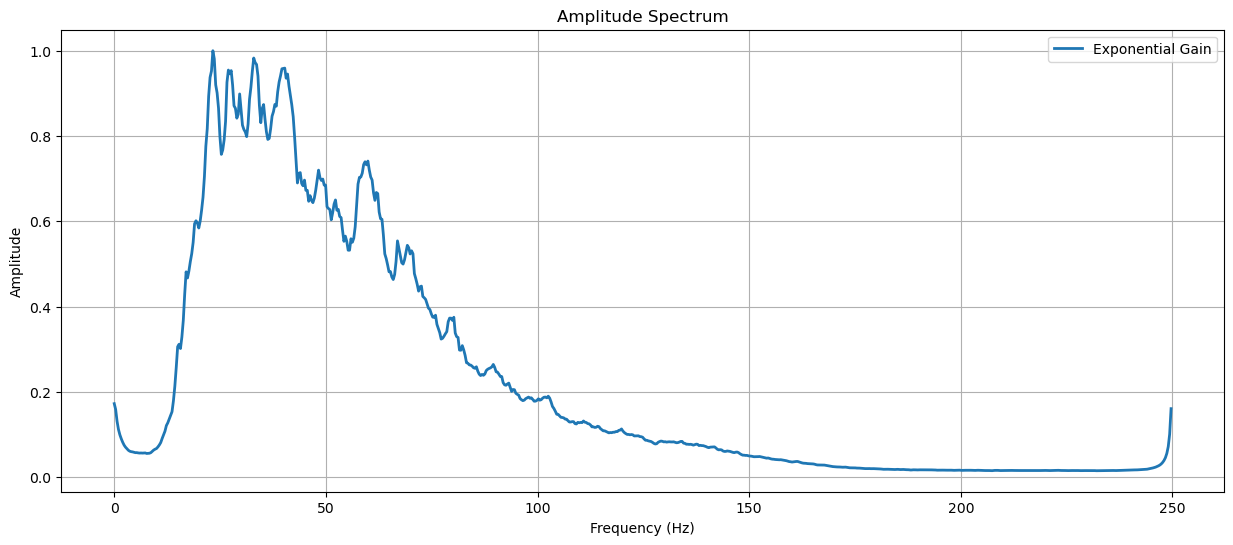

In [267]:
def plot_amplitude_spectrum_exp(data_exp, dt, label):

    # number of samples
    n_traces, n_samples = data_exp.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data_exp, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_exp(data_exp, dt, "Exponential Gain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum.jpg", dpi=600, bbox_inches="tight")

plt.show()

### 7 - Time-variant Gain in dB:  Applications on Seismic Data

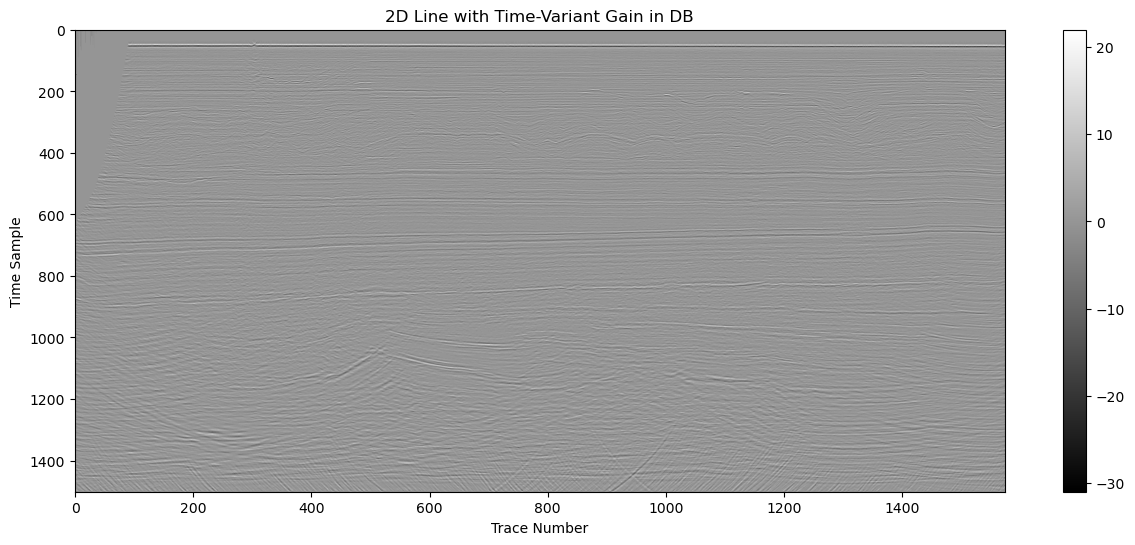

In [269]:
k = 0.5  # dB gain per second
gain_db = 10 ** (k * t / 20)

data_db = data * gain_db

#Ploting data

plt.figure(figsize=(15, 6))
plt.imshow(data_agc.T, cmap="grey", aspect="auto")
plt.title("2D Line with Time-Variant Gain in DB")
plt.xlabel("Trace Number")
plt.ylabel("Time Sample")
plt.colorbar()
#plt.gca().invert_yaxis()

#to save figure as png
plt.savefig("9. TVG.jpg", dpi=600, bbox_inches="tight")

plt.show()

#### 7.1 - Amplitude Spectrum: Time-variant Gain in dB

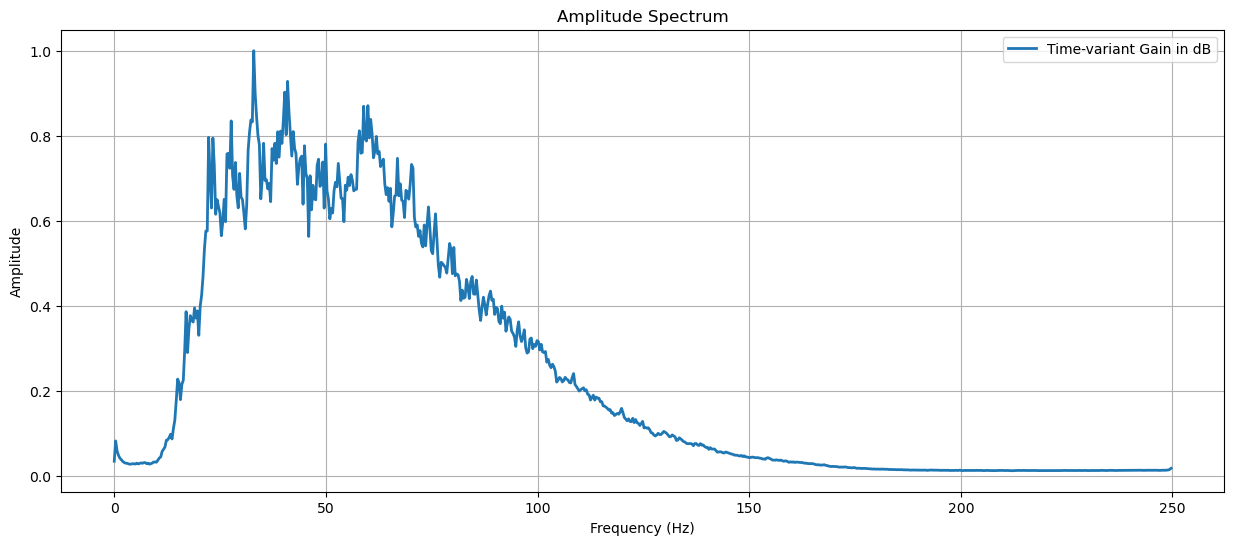

In [271]:
def plot_amplitude_spectrum_db(data_db, dt, label):

    # number of samples
    n_traces, n_samples = data_db.shape
    dt = 0.002   # 2 ms sampling
    # FFT
    fft_data = np.fft.fft(data_db, axis=1)

    # amplitude spectrum
    amp = np.mean(np.abs(fft_data), axis=0)

    # frequency axis
    freq = np.fft.fftfreq(n_samples, d=dt)

    # keep positive frequencies
    mask = freq >= 0
    freq = freq[mask]
    amp = amp[mask]

    # normalize
    amp = amp / np.max(amp)
    
    # plot
    plt.plot(freq, amp, linewidth=2, label=label)
plt.figure(figsize=(15,6))
plot_amplitude_spectrum_db(data_db, dt, "Time-variant Gain in dB")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.legend()
plt.grid(True)
plt.savefig("Amplitude_Spectrum.jpg", dpi=600, bbox_inches="tight")

plt.show()

### All Amplitude Spectrum : Plot OverLay

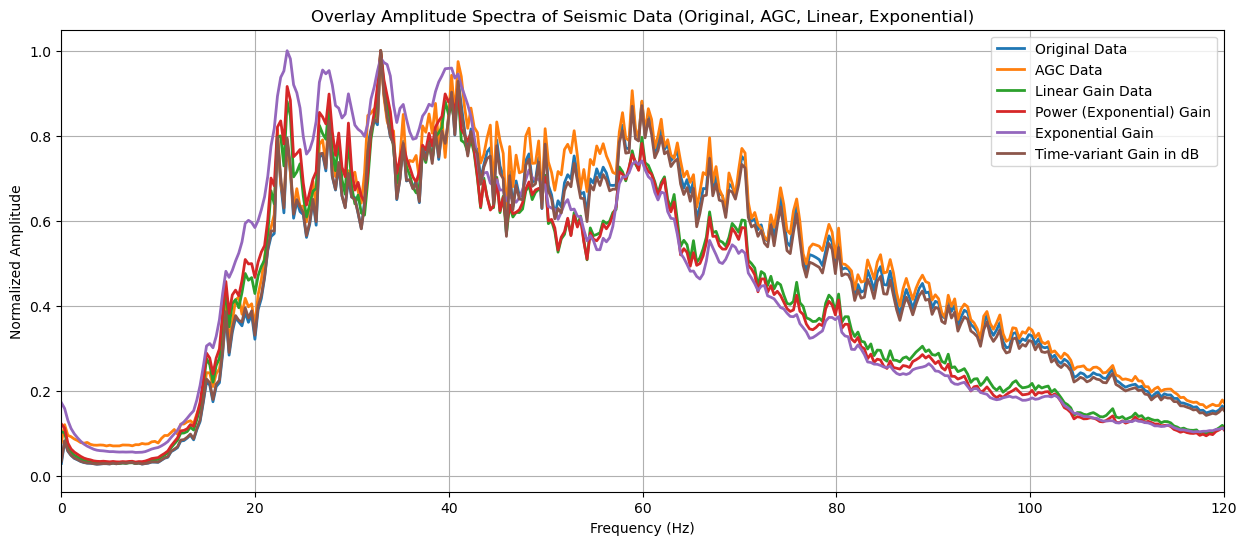

In [274]:
# -----------------------------
# Plot overlay
# -----------------------------
plt.figure(figsize=(15,6))

plot_amplitude_spectrum_ori(data, dt, "Original Data")
plot_amplitude_spectrum_agc(data_agc, dt, "AGC Data")
plot_amplitude_spectrum_linear(data_linear_gain, dt, "Linear Gain Data")
plot_amplitude_spectrum_power(data_power, dt, "Power (Exponential) Gain")
plot_amplitude_spectrum_exp(data_exp, dt, "Exponential Gain")
plot_amplitude_spectrum_db(data_db, dt, "Time-variant Gain in dB")
#plt.plot(freq, data, label="Original Data", linewidth=2)
#plt.plot(freq, data_agc, label="AGC Data", linewidth=2)
#plt.plot(freq, amp_linear, label="Linear Gain", linewidth=2)
#plt.plot(freq, amp_exp, label="Exponential Gain", linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.title("Overlay Amplitude Spectra of Seismic Data (Original, AGC, Linear, Exponential)")
plt.legend()
plt.grid(True)
plt.xlim(0, 120)  # Adjust max frequency to your seismic data bandwidth
plt.show()

---
## Thank you for Learning about Seismic Gains
---